In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import requests
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Define the endpoint and parameters
endpoint = 'https://archive-api.open-meteo.com/v1/archive'
params = {
    'latitude': -34.9285,       # Latitude for Adelaide
    'longitude': 138.6007,      # Longitude for Adelaide
    'start_date': datetime(2026, 6, 1).strftime('%Y-%m-%d'),
    'end_date': datetime(2026, 8, 31).strftime('%Y-%m-%d'),
    'daily': 'temperature_2m_mean',
    'timezone': 'Australia/Adelaide'
}

In [3]:
response = requests.get(endpoint, params=params)
response.raise_for_status()

wdata = response.json()

In [4]:
# %%
# Extract the daily temperature data
timestamps = [
    datetime.fromisoformat(item)
    for item in wdata['daily']['time']
]

temperatures = wdata['daily']['temperature_2m_mean']

# Create a DataFrame
wdf = pd.DataFrame({
    'Date': timestamps,
    'Temp': temperatures
})

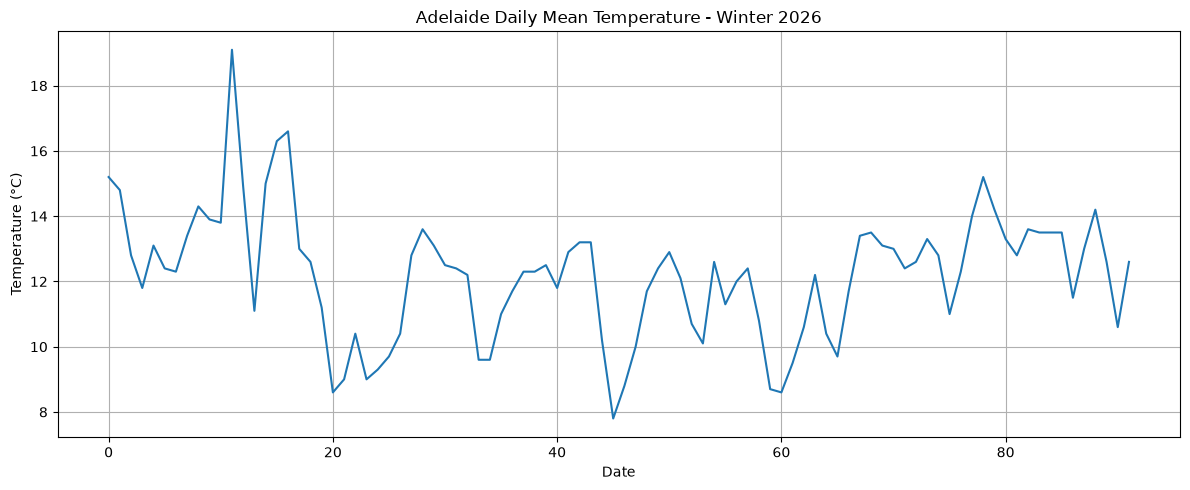

In [5]:
# %%
# Plot the daily temperature data
plt.figure(figsize=(12, 5))

plt.plot(wdf.index, wdf['Temp'])

plt.title("Adelaide Daily Mean Temperature - Winter 2026")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Split data into training and test sets
train_size = int(len(wdf) * 0.8)
train, test = wdf['Temp'][:train_size], wdf['Temp'][train_size:]
# Fit the model on the training set
arimamodel = ARIMA(train, order=(5, 1, 0))
arimamodel_fit = arimamodel.fit()
# Make predictions on the test set
predictions = arimamodel_fit.forecast(steps=len(test))

In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Assuming 'actual' and 'predictions' are arrays/lists of equal length
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"RMSE: {rmse}")

RMSE: 1.1215026010894689
